In [10]:
# Explainability with leakage-safe preprocessing and patient-aware split
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, brier_score_loss, f1_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit, train_test_split

SEED = 42

# Load processed dataset
df = pd.read_csv("../data/processed/icu_features.csv")

# Define features and target
features = [
    "age",
    "gender",
    "heart_rate",
    "sbp",
    "dbp",
    "mbp",
    "resp_rate",
    "spo2",
    "temperature",
]

X = df[features].copy()
y = df["mortality"].astype(int)

# Build train/val/test splits (60/20/20 total)
if "subject_id" in df.columns:
    groups = df.loc[X.index, "subject_id"]

    # Split off test set first
    gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_val_idx, test_idx = next(gss_test.split(X, y, groups=groups))

    X_train_val = X.iloc[train_val_idx].copy()
    y_train_val = y.iloc[train_val_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_test = y.iloc[test_idx].copy()

    groups_train_val = groups.iloc[train_val_idx]

    # Split train and validation from remaining data
    gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
    train_rel_idx, val_rel_idx = next(
        gss_val.split(X_train_val, y_train_val, groups=groups_train_val)
    )

    X_train = X_train_val.iloc[train_rel_idx].copy()
    y_train = y_train_val.iloc[train_rel_idx].copy()
    X_val = X_train_val.iloc[val_rel_idx].copy()
    y_val = y_train_val.iloc[val_rel_idx].copy()

    split_mode = "grouped_by_subject_id"
else:
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.25, random_state=SEED, stratify=y_train_val
    )
    split_mode = "stratified_random"

# Leakage-safe imputation: fit on train only
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=features, index=X_train.index)
X_val_imp = pd.DataFrame(imputer.transform(X_val), columns=features, index=X_val.index)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=features, index=X_test.index)

# Train model
model = GradientBoostingClassifier(random_state=SEED)
model.fit(X_train_imp, y_train)

print(f"Split mode: {split_mode}")
print(
    f"Train size: {len(X_train_imp)}, Val size: {len(X_val_imp)}, Test size: {len(X_test_imp)}"
 )

Split mode: grouped_by_subject_id
Train size: 1286, Val size: 399, Test size: 419


In [11]:
# Evaluate model and tune classification threshold on validation set
val_probs = model.predict_proba(X_val_imp)[:, 1]
test_probs = model.predict_proba(X_test_imp)[:, 1]

thresholds = np.linspace(0.10, 0.90, 17)
best_threshold = max(
    thresholds,
    key=lambda t: f1_score(y_val, (val_probs >= t).astype(int), zero_division=0),
)

test_pred_05 = (test_probs >= 0.5).astype(int)
test_pred_best = (test_probs >= best_threshold).astype(int)

roc_auc = roc_auc_score(y_test, test_probs)
pr_auc = average_precision_score(y_test, test_probs)
f1_05 = f1_score(y_test, test_pred_05, zero_division=0)
f1_best = f1_score(y_test, test_pred_best, zero_division=0)
brier = brier_score_loss(y_test, test_probs)

print(f"Best validation threshold: {best_threshold:.2f}")
print(f"Test ROC-AUC: {roc_auc:.4f}")
print(f"Test PR-AUC: {pr_auc:.4f}")
print(f"Test F1@0.5: {f1_05:.4f}")
print(f"Test F1@best_threshold: {f1_best:.4f}")
print(f"Test Brier score: {brier:.4f}")

Best validation threshold: 0.20
Test ROC-AUC: 0.7439
Test PR-AUC: 0.3877
Test F1@0.5: 0.2432
Test F1@best_threshold: 0.3571
Test Brier score: 0.1082


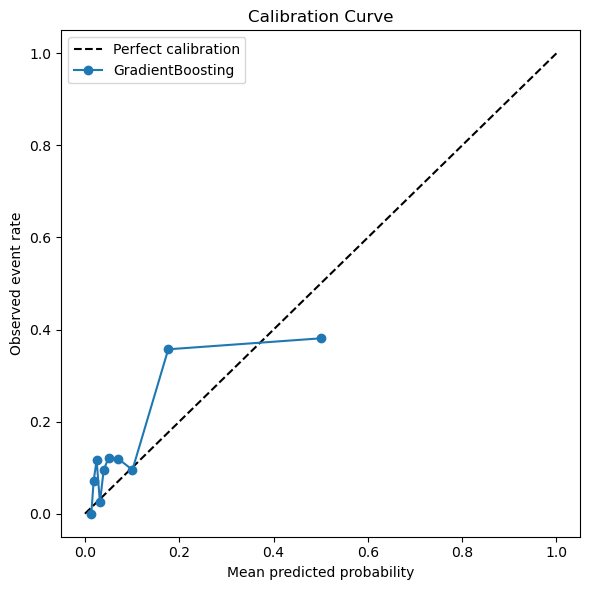

In [12]:
# Calibration curve (reliability diagram)
frac_pos, mean_pred = calibration_curve(y_test, test_probs, n_bins=10, strategy="quantile")

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.plot(mean_pred, frac_pos, marker="o", label="GradientBoosting")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed event rate")
plt.title("Calibration Curve")
plt.legend()
plt.tight_layout()
plt.show()

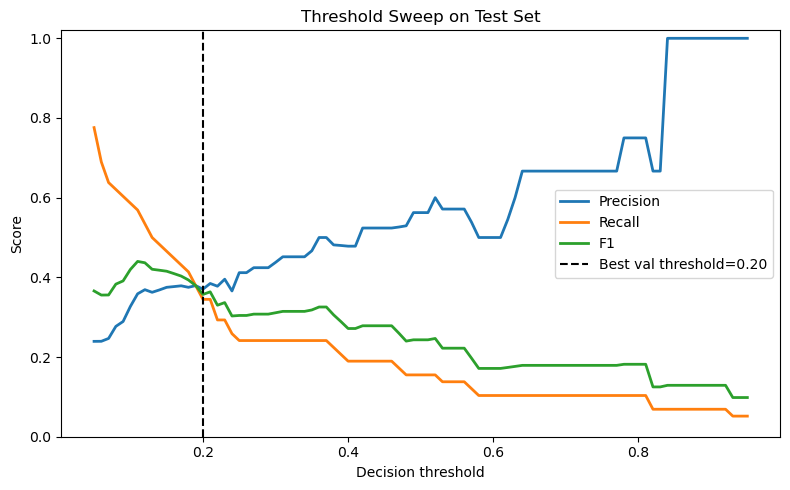

Saved: ../results/figures/threshold_sweep.png


In [13]:
# Decision-threshold sweep plot (precision, recall, F1)
from sklearn.metrics import precision_score, recall_score

threshold_grid = np.linspace(0.05, 0.95, 91)
precision_vals, recall_vals, f1_vals = [], [], []

for t in threshold_grid:
    pred_t = (test_probs >= t).astype(int)
    precision_vals.append(precision_score(y_test, pred_t, zero_division=0))
    recall_vals.append(recall_score(y_test, pred_t, zero_division=0))
    f1_vals.append(f1_score(y_test, pred_t, zero_division=0))

plt.figure(figsize=(8, 5))
plt.plot(threshold_grid, precision_vals, label="Precision", linewidth=2)
plt.plot(threshold_grid, recall_vals, label="Recall", linewidth=2)
plt.plot(threshold_grid, f1_vals, label="F1", linewidth=2)
plt.axvline(best_threshold, color="black", linestyle="--", label=f"Best val threshold={best_threshold:.2f}")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("Threshold Sweep on Test Set")
plt.ylim(0, 1.02)
plt.legend()
plt.tight_layout()

os.makedirs("../results/figures", exist_ok=True)
plt.savefig("../results/figures/threshold_sweep.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved: ../results/figures/threshold_sweep.png")

In [14]:
# Bootstrap 95% confidence intervals for ROC-AUC and PR-AUC
def bootstrap_metric_ci(y_true, y_prob, metric_fn, n_boot=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n = len(y_true)
    scores = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        y_b = y_true[idx]
        p_b = y_prob[idx]

        # Skip samples with a single class, where AUC/AP are undefined
        if len(np.unique(y_b)) < 2:
            continue
        scores.append(metric_fn(y_b, p_b))

    if not scores:
        return np.nan, np.nan, np.nan

    scores = np.asarray(scores)
    return float(scores.mean()), float(np.percentile(scores, 2.5)), float(np.percentile(scores, 97.5))

roc_mean, roc_lo, roc_hi = bootstrap_metric_ci(y_test, test_probs, roc_auc_score)
pr_mean, pr_lo, pr_hi = bootstrap_metric_ci(y_test, test_probs, average_precision_score)

print(f"ROC-AUC bootstrap mean: {roc_mean:.4f} | 95% CI [{roc_lo:.4f}, {roc_hi:.4f}]")
print(f"PR-AUC bootstrap mean:  {pr_mean:.4f} | 95% CI [{pr_lo:.4f}, {pr_hi:.4f}]")

ROC-AUC bootstrap mean: 0.7448 | 95% CI [0.6719, 0.8129]
PR-AUC bootstrap mean:  0.3963 | 95% CI [0.2767, 0.5165]


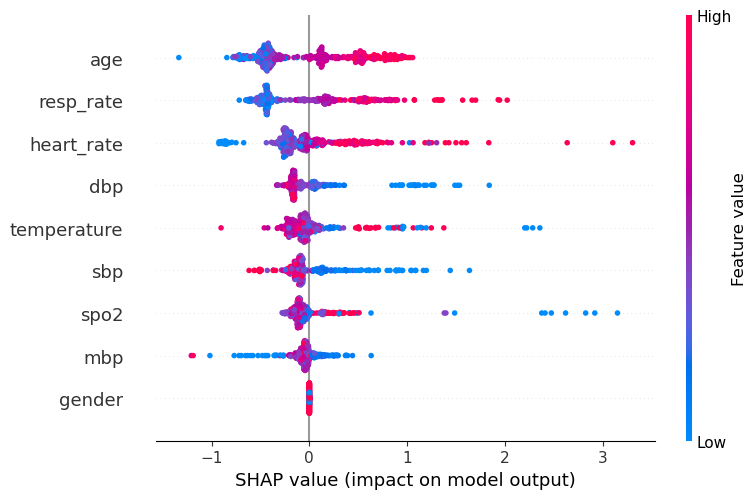

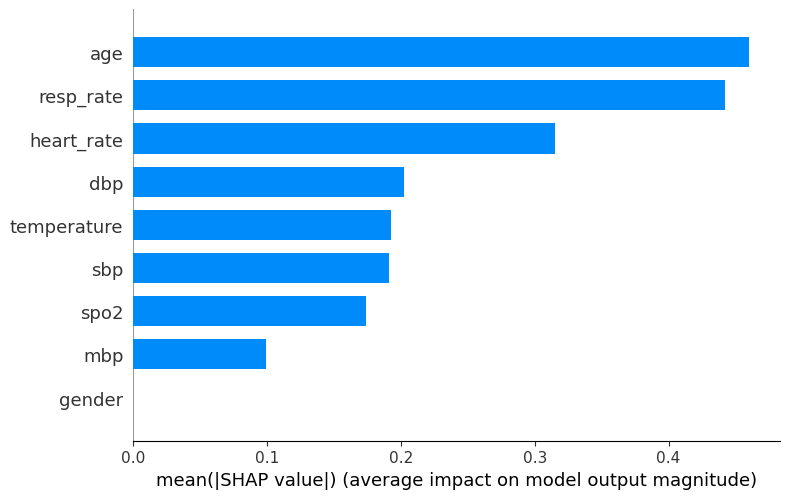

In [15]:
# Compute SHAP values with a version-robust API
import shap

required = ["model", "X_test_imp"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        f"Missing {missing}. Run the model/data preparation cells first."
    )

explainer = shap.TreeExplainer(model)

# SHAP >= 0.40 often prefers explainer(data) and returns Explanation
shap_exp = explainer(X_test_imp)
shap_values = shap_exp.values if hasattr(shap_exp, "values") else shap_exp

# Global explainability plots
shap.summary_plot(shap_values, X_test_imp)
shap.summary_plot(shap_values, X_test_imp, plot_type="bar") # type: ignore

In [16]:
# SHAP force plot for a single patient
import shap

required = ["explainer", "shap_values", "X_test_imp"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        f"Missing {missing}. Run the SHAP value computation cell first."
    )

shap.initjs()

base_value = shap_exp.base_values[0] if "shap_exp" in globals() and hasattr(shap_exp, "base_values") else explainer.expected_value
sample_values = shap_values[0]
sample_features = X_test_imp.iloc[0]

shap.force_plot(base_value, sample_values, sample_features)

Saved: ../results/shap/force_plot_patient_0.html
Saved: ../results/figures/force_plot_patient_0.png


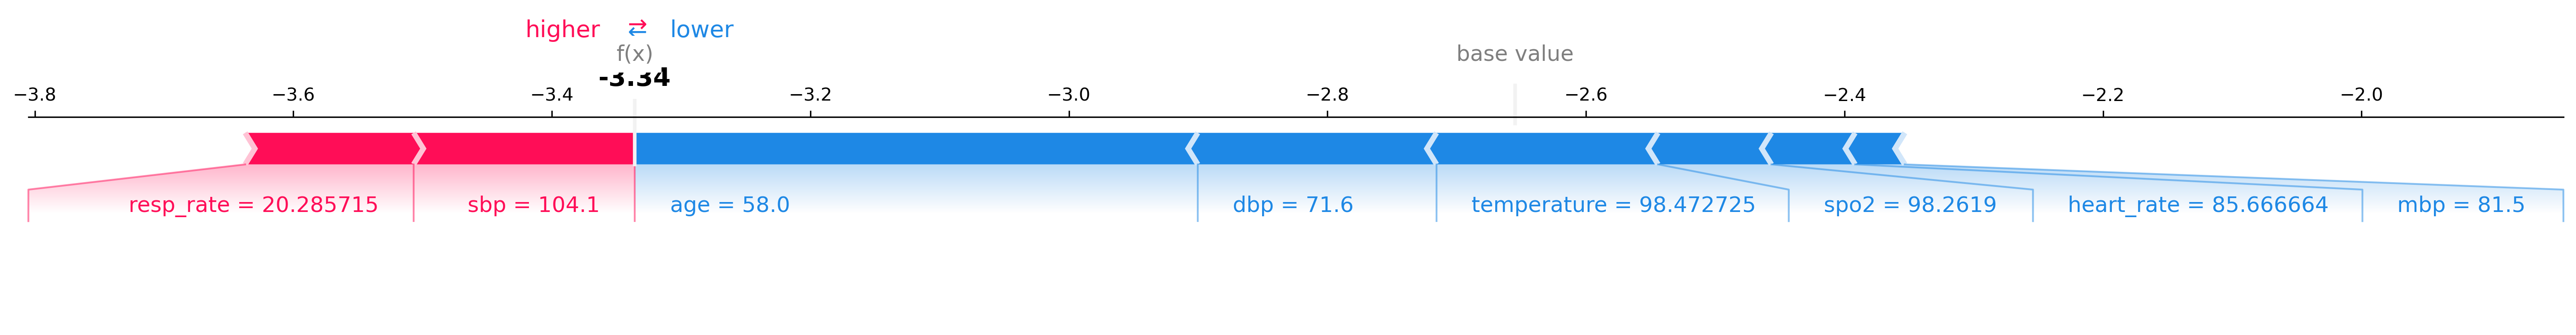

<Figure size 1200x300 with 0 Axes>

In [17]:
# Export force plot for GitHub (static PNG) and local interactive view (HTML)
import os
import shap
import matplotlib.pyplot as plt
from IPython.display import Image, display

os.makedirs("../results/figures", exist_ok=True)
os.makedirs("../results/shap", exist_ok=True)

# Rebuild force-plot inputs if they are not already available in this session
if "sample_values" not in globals() and "shap_values" in globals():
    sample_values = shap_values[0]
if "sample_features" not in globals() and "X_test_imp" in globals():
    sample_features = X_test_imp.iloc[0]
if "base_value" not in globals() and "explainer" in globals():
    if "shap_exp" in globals() and hasattr(shap_exp, "base_values"):
        base_value = shap_exp.base_values[0]
    else:
        base_value = explainer.expected_value

required = ["base_value", "sample_values", "sample_features"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        f"Missing {missing}. Run the previous SHAP cells first to compute explainer/shap_values."
    )

# Interactive HTML (recommended for browser/GitHub Pages viewing)
force_plot_html = shap.force_plot(base_value, sample_values, sample_features)
shap.save_html("../results/shap/force_plot_patient_0.html", force_plot_html)

# Static PNG fallback (renders on GitHub notebook preview)
plt.figure(figsize=(12, 3))
shap.force_plot(base_value, sample_values, sample_features, matplotlib=True, show=False)
plt.tight_layout()
plt.savefig("../results/figures/force_plot_patient_0.png", dpi=300, bbox_inches="tight")
plt.close()

print("Saved: ../results/shap/force_plot_patient_0.html")
print("Saved: ../results/figures/force_plot_patient_0.png")

# Show static image inline so GitHub preview can display it
display(Image(filename="../results/figures/force_plot_patient_0.png"))

In [18]:
# Save SHAP summary plot and feature importance table
plt.figure()
shap.summary_plot(shap_values, X_test_imp, show=False)
plt.tight_layout()
plt.savefig("../results/figures/shap_summary.png", dpi=300, bbox_inches="tight")
plt.close()

# Export mean absolute SHAP importances
shap_importance_df = pd.DataFrame(
    {
        "feature": X_test_imp.columns,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    }
).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

os.makedirs("../results/shap", exist_ok=True)
shap_importance_df.to_csv("../results/shap/shap_feature_importance.csv", index=False)

print("Saved: ../results/figures/shap_summary.png")
print("Saved: ../results/shap/shap_feature_importance.csv")
shap_importance_df

Saved: ../results/figures/shap_summary.png
Saved: ../results/shap/shap_feature_importance.csv


,feature,mean_abs_shap
0,age,0.460178
1,resp_rate,0.442183
2,heart_rate,0.314807
3,dbp,0.202290
4,temperature,0.192949
5,sbp,0.190949
6,spo2,0.173650
7,mbp,0.099333
8,gender,0.000124


## Compact Interpretation 
The summary below is generated from the SHAP CSV so interpretation stays aligned with computed results.

In [19]:
# Auto-generate compact markdown interpretation from SHAP CSV
from IPython.display import Markdown, display

top_k = 5
shap_csv_path = "../results/shap/shap_feature_importance.csv"
shap_top = pd.read_csv(shap_csv_path).head(top_k).copy()
total_importance = shap_top["mean_abs_shap"].sum()

lines = [
    "### SHAP Interpretation Summary",
    f"Top {top_k} most influential features for mortality risk:",
    "",
]

for i, row in shap_top.iterrows():
    pct = (row["mean_abs_shap"] / total_importance * 100.0) if total_importance > 0 else 0.0
    lines.append(f"- {i+1}. **{row['feature']}** (mean |SHAP| = {row['mean_abs_shap']:.4f}, share = {pct:.1f}%)")

lines.extend([
    "",
    "Interpretation note: These values quantify average contribution magnitude, not direction or causality.",
    f"Model context: ROC-AUC={roc_auc:.3f}, PR-AUC={pr_auc:.3f}, F1@best_threshold={f1_best:.3f}.",
])

interpretation_md = "\n".join(lines)
display(Markdown(interpretation_md))

with open("../results/shap/shap_interpretation.md", "w", encoding="utf-8") as f:
    f.write(interpretation_md + "\n")

print("Saved: ../results/shap/shap_interpretation.md")

### SHAP Interpretation Summary
Top 5 most influential features for mortality risk:

- 1. **age** (mean |SHAP| = 0.4602, share = 28.5%)
- 2. **resp_rate** (mean |SHAP| = 0.4422, share = 27.4%)
- 3. **heart_rate** (mean |SHAP| = 0.3148, share = 19.5%)
- 4. **dbp** (mean |SHAP| = 0.2023, share = 12.5%)
- 5. **temperature** (mean |SHAP| = 0.1929, share = 12.0%)

Interpretation note: These values quantify average contribution magnitude, not direction or causality.
Model context: ROC-AUC=0.744, PR-AUC=0.388, F1@best_threshold=0.357.

Saved: ../results/shap/shap_interpretation.md


## Cross-Validated Robustness 
This section performs grouped cross-validation (when subject_id is available), validation-only threshold tuning, and calibrated vs uncalibrated comparison for stronger reliability claims.

CV mode: GroupKFold (5 folds)


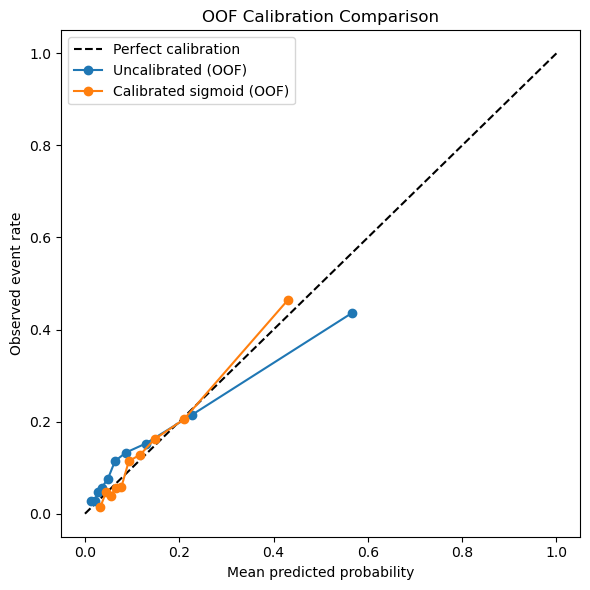

Saved: ../results/metrics/cv_fold_metrics.csv
Saved: ../results/metrics/cv_model_comparison.csv
Saved: ../results/figures/cv_calibration_comparison.png


,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,brier_mean,brier_std,ece_mean,ece_std,precision_mean,recall_mean,f1_mean,threshold_median,threshold_iqr_low,threshold_iqr_high
0,calibrated_sigmoid,0.777445,0.028044,0.449096,0.073462,0.092706,0.01353,0.027865,0.007295,0.399760,0.432988,0.380885,0.25,0.15,0.30
1,uncalibrated,0.764494,0.026535,0.422664,0.066743,0.097781,0.01358,0.048848,0.007132,0.364229,0.451122,0.386115,0.20,0.10,0.35


In [20]:
# Grouped CV with validation-only threshold selection and calibration comparison
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import GroupKFold, StratifiedKFold

def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    ece = 0.0
    n = len(y_true)

    for b in range(n_bins):
        mask = bin_ids == b
        if not np.any(mask):
            continue
        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += (mask.sum() / n) * abs(acc - conf)
    return float(ece)

# Prepare CV splitter
n_splits = 5
if "subject_id" in df.columns:
    cv_groups = df.loc[X.index, "subject_id"]
    cv_splitter = GroupKFold(n_splits=n_splits)
    cv_iterator = cv_splitter.split(X, y, groups=cv_groups)
    cv_mode = "GroupKFold"
else:
    cv_groups = None
    cv_splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    cv_iterator = cv_splitter.split(X, y)
    cv_mode = "StratifiedKFold"

print(f"CV mode: {cv_mode} ({n_splits} folds)")

threshold_grid = np.linspace(0.10, 0.90, 17)
fold_rows = []

# Out-of-fold containers for calibration comparison
oof_true = []
oof_prob_uncal = []
oof_prob_cal = []

base_template = GradientBoostingClassifier(random_state=SEED)

for fold, (train_idx_cv, val_idx_cv) in enumerate(cv_iterator, start=1):
    X_train_raw = X.iloc[train_idx_cv].copy()
    y_train_cv = y.iloc[train_idx_cv].copy()
    X_val_raw = X.iloc[val_idx_cv].copy()
    y_val_cv = y.iloc[val_idx_cv].copy()

    # Inner split for threshold tuning only (never using outer validation fold)
    if cv_groups is not None:
        g_train = cv_groups.iloc[train_idx_cv]
        gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED + fold)
        inner_train_rel, tune_rel = next(gss_inner.split(X_train_raw, y_train_cv, groups=g_train))
    else:
        rel_idx = np.arange(len(X_train_raw))
        inner_train_rel, tune_rel = train_test_split(
            rel_idx,
            test_size=0.2,
            random_state=SEED + fold,
            stratify=y_train_cv,
        )

    X_inner_train_raw = X_train_raw.iloc[inner_train_rel].copy()
    y_inner_train = y_train_cv.iloc[inner_train_rel].copy()
    X_tune_raw = X_train_raw.iloc[tune_rel].copy()
    y_tune = y_train_cv.iloc[tune_rel].copy()

    # Fold-local preprocessing (leakage-safe)
    fold_imputer = SimpleImputer(strategy="median")
    X_inner_train_imp = fold_imputer.fit_transform(X_inner_train_raw)
    X_tune_imp = fold_imputer.transform(X_tune_raw)
    X_val_imp = fold_imputer.transform(X_val_raw)

    # Uncalibrated model
    uncal_model = clone(base_template)
    uncal_model.fit(X_inner_train_imp, y_inner_train)

    tune_probs_uncal = uncal_model.predict_proba(X_tune_imp)[:, 1]
    best_thr_uncal = max(
        threshold_grid,
        key=lambda t: f1_score(y_tune, (tune_probs_uncal >= t).astype(int), zero_division=0),
    )

    val_probs_uncal = uncal_model.predict_proba(X_val_imp)[:, 1]
    val_pred_uncal = (val_probs_uncal >= best_thr_uncal).astype(int)

    # Calibrated model (sigmoid calibration on inner training folds only)
    cal_model = CalibratedClassifierCV(
        estimator=clone(base_template),
        method="sigmoid",
        cv=3,
    )
    cal_model.fit(X_inner_train_imp, y_inner_train)

    tune_probs_cal = cal_model.predict_proba(X_tune_imp)[:, 1]
    best_thr_cal = max(
        threshold_grid,
        key=lambda t: f1_score(y_tune, (tune_probs_cal >= t).astype(int), zero_division=0),
    )

    val_probs_cal = cal_model.predict_proba(X_val_imp)[:, 1]
    val_pred_cal = (val_probs_cal >= best_thr_cal).astype(int)

    # Store OOF for calibration comparison curve
    oof_true.extend(y_val_cv.tolist())
    oof_prob_uncal.extend(val_probs_uncal.tolist())
    oof_prob_cal.extend(val_probs_cal.tolist())

    fold_rows.extend([
        {
            "fold": fold,
            "model": "uncalibrated",
            "threshold": float(best_thr_uncal),
            "roc_auc": roc_auc_score(y_val_cv, val_probs_uncal),
            "pr_auc": average_precision_score(y_val_cv, val_probs_uncal),
            "brier": brier_score_loss(y_val_cv, val_probs_uncal),
            "ece": expected_calibration_error(y_val_cv, val_probs_uncal),
            "precision": precision_score(y_val_cv, val_pred_uncal, zero_division=0),
            "recall": recall_score(y_val_cv, val_pred_uncal, zero_division=0),
            "f1": f1_score(y_val_cv, val_pred_uncal, zero_division=0),
        },
        {
            "fold": fold,
            "model": "calibrated_sigmoid",
            "threshold": float(best_thr_cal),
            "roc_auc": roc_auc_score(y_val_cv, val_probs_cal),
            "pr_auc": average_precision_score(y_val_cv, val_probs_cal),
            "brier": brier_score_loss(y_val_cv, val_probs_cal),
            "ece": expected_calibration_error(y_val_cv, val_probs_cal),
            "precision": precision_score(y_val_cv, val_pred_cal, zero_division=0),
            "recall": recall_score(y_val_cv, val_pred_cal, zero_division=0),
            "f1": f1_score(y_val_cv, val_pred_cal, zero_division=0),
        },
    ])

cv_fold_df = pd.DataFrame(fold_rows)
cv_summary_df = (
    cv_fold_df.groupby("model", as_index=False)
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_std=("pr_auc", "std"),
        brier_mean=("brier", "mean"),
        brier_std=("brier", "std"),
        ece_mean=("ece", "mean"),
        ece_std=("ece", "std"),
        precision_mean=("precision", "mean"),
        recall_mean=("recall", "mean"),
        f1_mean=("f1", "mean"),
        threshold_median=("threshold", "median"),
        threshold_iqr_low=("threshold", lambda s: s.quantile(0.25)),
        threshold_iqr_high=("threshold", lambda s: s.quantile(0.75)),
    )
    .sort_values("roc_auc_mean", ascending=False)
    .reset_index(drop=True)
)

os.makedirs("../results/metrics", exist_ok=True)
cv_fold_df.to_csv("../results/metrics/cv_fold_metrics.csv", index=False)
cv_summary_df.to_csv("../results/metrics/cv_model_comparison.csv", index=False)

# Reliability comparison from OOF predictions
oof_true_arr = np.asarray(oof_true)
oof_uncal_arr = np.asarray(oof_prob_uncal)
oof_cal_arr = np.asarray(oof_prob_cal)

frac_uncal, mean_uncal = calibration_curve(oof_true_arr, oof_uncal_arr, n_bins=10, strategy="quantile")
frac_cal, mean_cal = calibration_curve(oof_true_arr, oof_cal_arr, n_bins=10, strategy="quantile")

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.plot(mean_uncal, frac_uncal, marker="o", label="Uncalibrated (OOF)")
plt.plot(mean_cal, frac_cal, marker="o", label="Calibrated sigmoid (OOF)")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed event rate")
plt.title("OOF Calibration Comparison")
plt.legend()
plt.tight_layout()

os.makedirs("../results/figures", exist_ok=True)
plt.savefig("../results/figures/cv_calibration_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved: ../results/metrics/cv_fold_metrics.csv")
print("Saved: ../results/metrics/cv_model_comparison.csv")
print("Saved: ../results/figures/cv_calibration_comparison.png")
cv_summary_df

## Final Holdout Report and Deployment Bundle
This section freezes holdout metrics, saves deployable artifacts, and documents limitations for transparent use.

In [31]:
# Freeze a holdout report JSON (do not tune on this after saving)
import json
from datetime import datetime, timezone

holdout_report = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "dataset": "../data/processed/icu_features.csv",
    "split_mode": split_mode,
    "n_train": int(len(X_train_imp)),
    "n_val": int(len(X_val_imp)),
    "n_test": int(len(X_test_imp)),
    "mortality_rate_test": float(np.mean(y_test)),
    "selected_threshold_from_validation": float(best_threshold),
    "test_metrics": {
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "f1_at_0_5": float(f1_05),
        "f1_at_selected_threshold": float(f1_best),
        "brier": float(brier),
    },
    "test_metric_ci95_bootstrap": {
        "roc_auc": [float(roc_lo), float(roc_hi)],
        "pr_auc": [float(pr_lo), float(pr_hi)],
    },
}

os.makedirs("../results/metrics", exist_ok=True)
with open("../results/metrics/holdout_report.json", "w", encoding="utf-8") as f:
    json.dump(holdout_report, f, indent=2)

print("Saved: ../results/metrics/holdout_report.json")
pd.DataFrame([holdout_report["test_metrics"]])

Saved: ../results/metrics/holdout_report.json


,roc_auc,pr_auc,f1_at_0_5,f1_at_selected_threshold,brier
0,0.743934,0.387673,0.243243,0.357143,0.108159


In [33]:
# Save deployable inference bundle and verify load/predict
import pickle

bundle = {
    "model": model,
    "imputer": imputer,
    "features": features,
    "threshold": float(best_threshold),
    "seed": int(SEED),
    "split_mode": split_mode,
    "notes": "Generated from notebook 05_explainability_shap.ipynb",
}

os.makedirs("../models", exist_ok=True)
bundle_path = "../models/gb_shap_inference_bundle.pkl"
with open(bundle_path, "wb") as f:
    pickle.dump(bundle, f)

# Quick reload test for reproducibility
with open(bundle_path, "rb") as f:
    loaded_bundle = pickle.load(f)

sample_input = X_test.iloc[[0]][loaded_bundle["features"]]
sample_imp = loaded_bundle["imputer"].transform(sample_input)
sample_imp_df = pd.DataFrame(sample_imp, columns=loaded_bundle["features"], index=sample_input.index)
sample_prob = float(loaded_bundle["model"].predict_proba(sample_imp_df)[0, 1])
sample_pred = int(sample_prob >= loaded_bundle["threshold"])

print(f"Saved: {bundle_path}")
print(f"Reload check -> sample_prob={sample_prob:.4f}, sample_pred={sample_pred}")

Saved: ../models/gb_shap_inference_bundle.pkl
Reload check -> sample_prob=0.0344, sample_pred=0


In [9]:
#Final Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

pred_labels = (test_probs > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, pred_labels))
print("Precision:", precision_score(y_test, pred_labels))
print("Recall:", recall_score(y_test, pred_labels))
print("F1 Score:", f1_score(y_test, pred_labels))
print("AUC:", roc_auc_score(y_test, test_probs))

Accuracy: 0.8663484486873508
Precision: 0.5625
Recall: 0.15517241379310345
F1 Score: 0.24324324324324326
AUC: 0.74393447320661


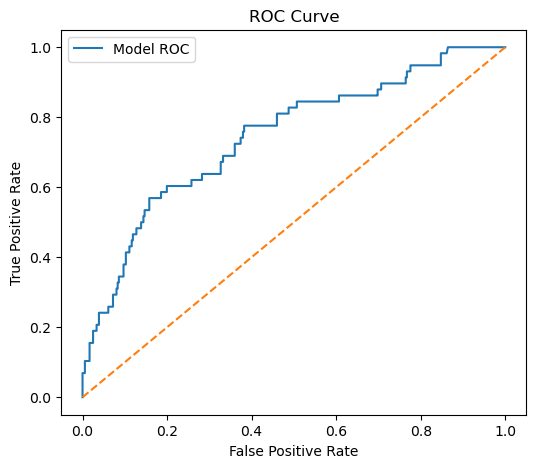

In [8]:
#Plot ROC Curve :a visualization showing model performance.
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, test_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Model ROC")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

os.makedirs("../results/figures", exist_ok=True)
plt.savefig("../results/figures/roc_curve.png", dpi=300)

plt.show()

## Limitations
- This analysis is observational and should not be interpreted as causal inference.
- Performance may vary across hospitals, ICU types, and time periods (distribution shift risk).
- The selected threshold is optimized for this dataset setup and must be revalidated before deployment.
- SHAP explains model behavior, not clinical causality.
- Prospective validation and clinical governance are required before patient-facing use.